In [7]:
import pandas as pd
import seaborn as sns

df = sns.load_dataset("titanic")
print(df.head())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


In [8]:
# Save the dataset as an offline fallback
df.to_csv("titanic.csv", index=False)

print("Titanic dataset saved successfully.")

Titanic dataset saved successfully.


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [10]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [11]:
print("Shape of dataset:", df.shape)

Shape of dataset: (891, 15)


In [12]:
# Calculate missing-value percentage for every column
missing_percentage = df.isnull().mean() * 100

# Show only columns that have missing values
missing_percentage = missing_percentage[missing_percentage > 0]

print("Missing-value percentages:")
print(missing_percentage)

Missing-value percentages:
age            19.865320
embarked        0.224467
deck           77.216611
embark_town     0.224467
dtype: float64


In [13]:
# Make a copy so we preserve the originally loaded dataset
df_clean = df.copy()

# 1. Age: median imputation
df_clean["age"] = df_clean["age"].fillna(df_clean["age"].median())

# 2. Drop rows where embarked or embark_town is missing
df_clean = df_clean.dropna(subset=["embarked", "embark_town"])

# 3. Drop deck because it has 77.22% missing values
df_clean = df_clean.drop(columns=["deck"])

# Check remaining missing values
print("Remaining missing values:")
print(df_clean.isnull().sum())

print("\nCleaned dataset shape:")
print(df_clean.shape)

Remaining missing values:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

Cleaned dataset shape:
(889, 14)


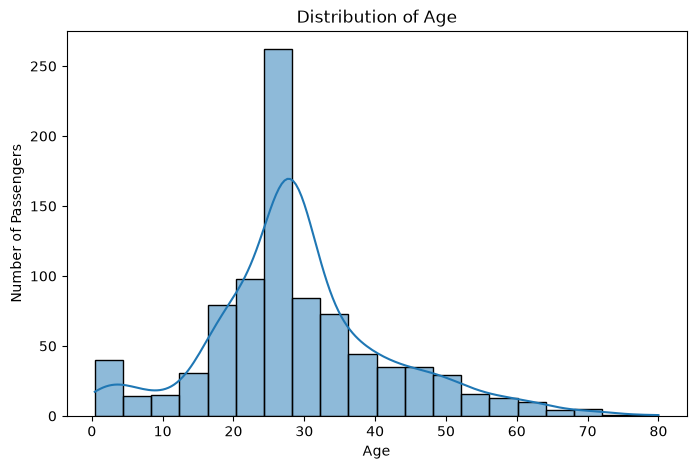

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histogram of age
plt.figure(figsize=(8, 5))
sns.histplot(df_clean["age"], bins=20, kde=True)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()

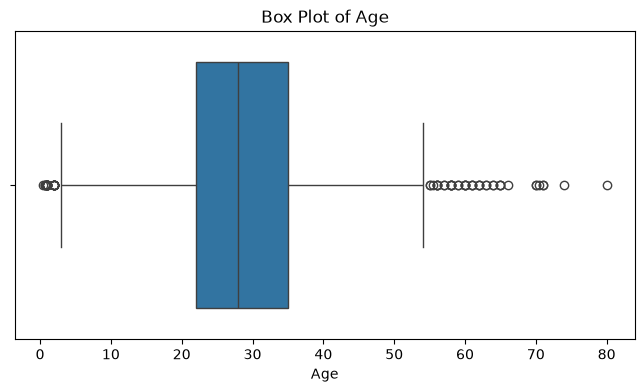

In [15]:
# Box plot of age

plt.figure(figsize=(8, 4))
sns.boxplot(x=df_clean["age"])
plt.title("Box Plot of Age")
plt.xlabel("Age")
plt.show()

In [16]:
# Calculate age outliers using the IQR rule

Q1_age = df_clean["age"].quantile(0.25)
Q3_age = df_clean["age"].quantile(0.75)

IQR_age = Q3_age - Q1_age

lower_age = Q1_age - 1.5 * IQR_age
upper_age = Q3_age + 1.5 * IQR_age

age_outliers = df_clean[
    (df_clean["age"] < lower_age) |
    (df_clean["age"] > upper_age)
]

print("Q1:", Q1_age)
print("Q3:", Q3_age)
print("IQR:", IQR_age)
print("Lower bound:", lower_age)
print("Upper bound:", upper_age)
print("Number of age outliers:", len(age_outliers))

Q1: 22.0
Q3: 35.0
IQR: 13.0
Lower bound: 2.5
Upper bound: 54.5
Number of age outliers: 65


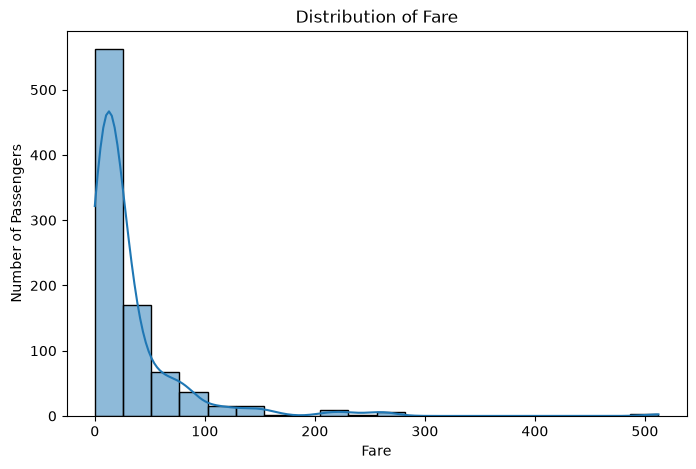

In [17]:
# Histogram of fare
plt.figure(figsize=(8, 5))
sns.histplot(df_clean["fare"], bins=20, kde=True)
plt.title("Distribution of Fare")
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")
plt.show()

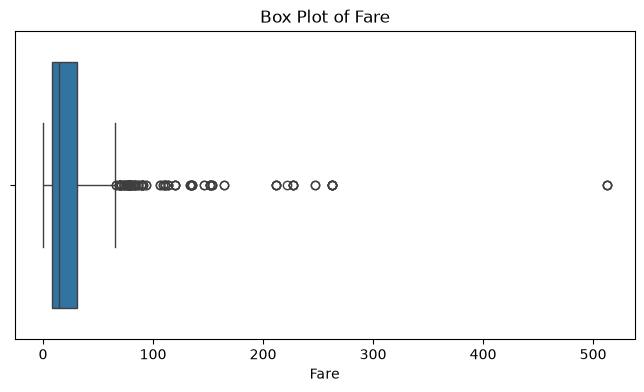

In [18]:
# Box plot of fare
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_clean["fare"])
plt.title("Box Plot of Fare")
plt.xlabel("Fare")
plt.show()

In [19]:
# Calculate fare outliers using the IQR rule

Q1_fare = df_clean["fare"].quantile(0.25)
Q3_fare = df_clean["fare"].quantile(0.75)

IQR_fare = Q3_fare - Q1_fare

lower_fare = Q1_fare - 1.5 * IQR_fare
upper_fare = Q3_fare + 1.5 * IQR_fare

fare_outliers = df_clean[
    (df_clean["fare"] < lower_fare) |
    (df_clean["fare"] > upper_fare)
]

print("Q1:", Q1_fare)
print("Q3:", Q3_fare)
print("IQR:", IQR_fare)
print("Lower bound:", lower_fare)
print("Upper bound:", upper_fare)
print("Number of fare outliers:", len(fare_outliers))

Q1: 7.8958
Q3: 31.0
IQR: 23.1042
Lower bound: -26.7605
Upper bound: 65.6563
Number of fare outliers: 114


In [20]:
# Mean, median and mode of fare

fare_mean = df_clean["fare"].mean()
fare_median = df_clean["fare"].median()
fare_mode = df_clean["fare"].mode()[0]

print("Mean:", fare_mean)
print("Median:", fare_median)
print("Mode:", fare_mode)

Mean: 32.09668087739032
Median: 14.4542
Mode: 8.05


In [21]:
# Survival rate by sex

survival_by_sex = (
    df_clean.groupby("sex")["survived"]
    .mean()
    .mul(100)
)

print("Survival rate by sex:")
print(survival_by_sex)

Survival rate by sex:
sex
female    74.038462
male      18.890815
Name: survived, dtype: float64


In [22]:
# Survival rate by passenger class

survival_by_pclass = (
    df_clean.groupby("pclass")["survived"]
    .mean()
    .mul(100)
)

print("Survival rate by passenger class:")
print(survival_by_pclass)

Survival rate by passenger class:
pclass
1    62.616822
2    47.282609
3    24.236253
Name: survived, dtype: float64


In [23]:
# Survival rate by sex and passenger class

survival_by_sex_pclass = (
    df_clean.groupby(["sex", "pclass"])["survived"]
    .mean()
    .mul(100)
)

print("Survival rate by sex and passenger class:")
print(survival_by_sex_pclass)

Survival rate by sex and passenger class:
sex     pclass
female  1         96.739130
        2         92.105263
        3         50.000000
male    1         36.885246
        2         15.740741
        3         13.544669
Name: survived, dtype: float64


In [24]:
# Correlation matrix using exactly the required six columns

corr_columns = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

corr_matrix = df_clean[corr_columns].corr()

print("Correlation Matrix:")
print(corr_matrix)

Correlation Matrix:
          survived    pclass       age     sibsp     parch      fare
survived  1.000000 -0.335549 -0.069822 -0.034040  0.083151  0.255290
pclass   -0.335549  1.000000 -0.336512  0.081656  0.016824 -0.548193
age      -0.069822 -0.336512  1.000000 -0.232543 -0.171485  0.093707
sibsp    -0.034040  0.081656 -0.232543  1.000000  0.414542  0.160887
parch     0.083151  0.016824 -0.171485  0.414542  1.000000  0.217532
fare      0.255290 -0.548193  0.093707  0.160887  0.217532  1.000000


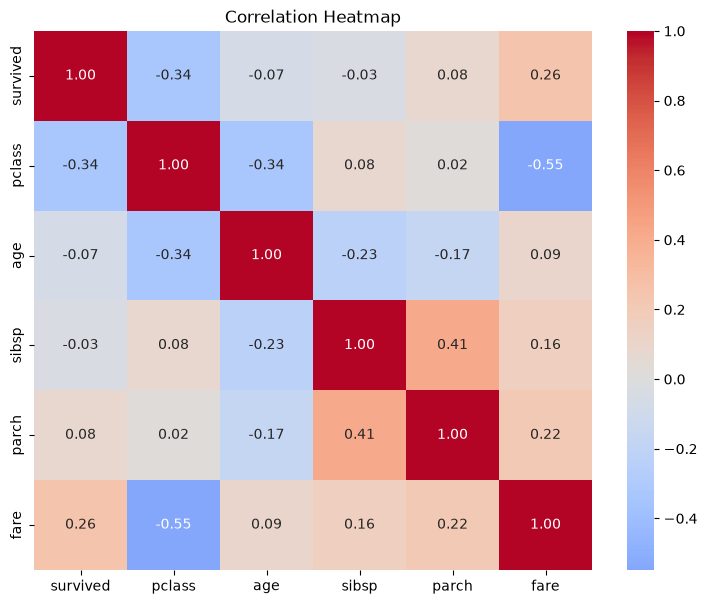

In [25]:
# Correlation heatmap

plt.figure(figsize=(9, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.show()

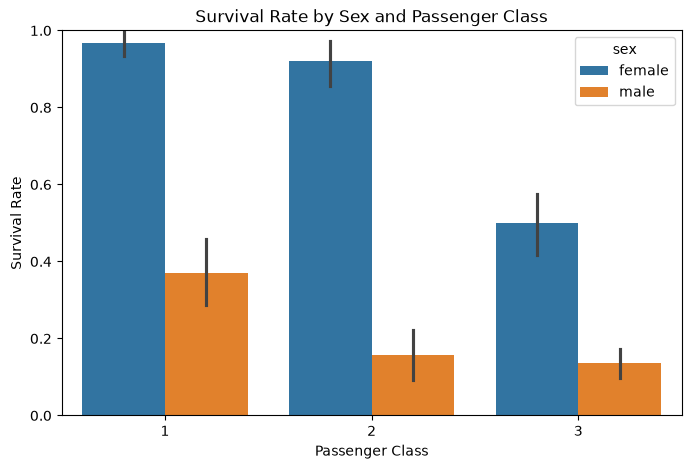

In [26]:
# Chart 1: Survival rate by sex and passenger class

plt.figure(figsize=(8, 5))

sns.barplot(
    data=df_clean,
    x="pclass",
    y="survived",
    hue="sex"
)

plt.title("Survival Rate by Sex and Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)

plt.show()

In [27]:
# Create age groups

df_clean["age_group"] = pd.cut(
    df_clean["age"],
    bins=[0, 18, 30, 50, float("inf")],
    labels=["Child", "Young Adult", "Adult", "Older Adult"],
    include_lowest=True
)

print(df_clean["age_group"].value_counts())

age_group
Young Adult    447
Adult          240
Child          139
Older Adult     63
Name: count, dtype: int64


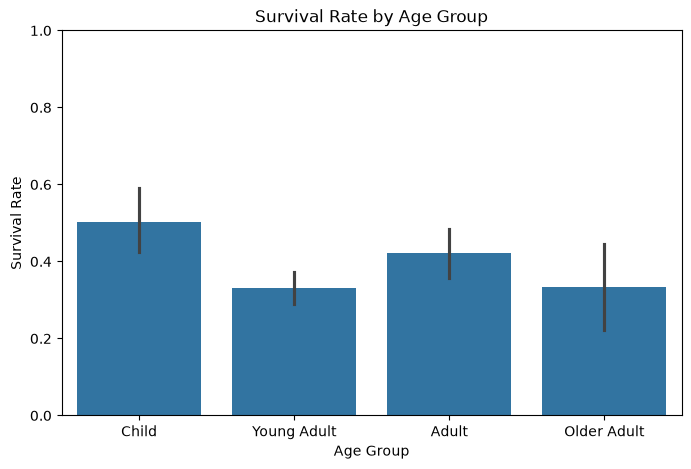

In [28]:
# Chart 2: Survival rate by age group

plt.figure(figsize=(8, 5))

sns.barplot(
    data=df_clean,
    x="age_group",
    y="survived"
)

plt.title("Survival Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)

plt.show()

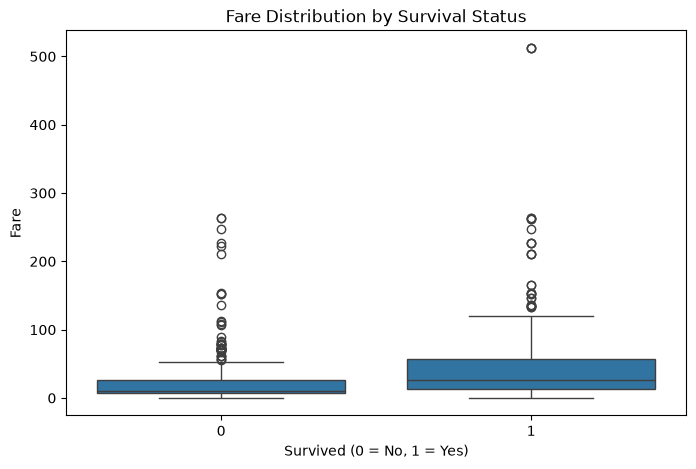

In [29]:
# Chart 3: Fare distribution by survival status

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="survived",
    y="fare"
)

plt.title("Fare Distribution by Survival Status")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Fare")

plt.show()

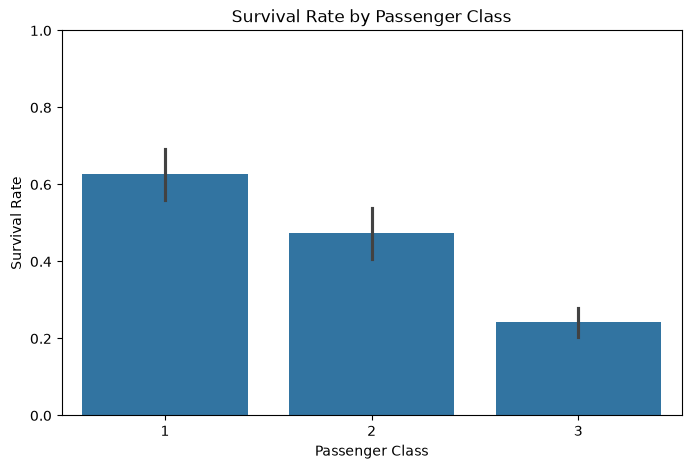

In [30]:
# Chart 4: Survival rate by passenger class

plt.figure(figsize=(8, 5))

sns.barplot(
    data=df_clean,
    x="pclass",
    y="survived"
)

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)

plt.show()

In [31]:
# Task 6: Standardization sanity check

print("Before standardization:")
print("Age mean:", df_clean["age"].mean())
print("Age std:", df_clean["age"].std())
print("Fare mean:", df_clean["fare"].mean())
print("Fare std:", df_clean["fare"].std())

Before standardization:
Age mean: 29.315151856017994
Age std: 12.984932293690775
Fare mean: 32.09668087739032
Fare std: 49.697504316707956


In [32]:
# Standardize age and fare using the z-score formula

df_standardized = df_clean.copy()

df_standardized["age_z"] = (
    (df_standardized["age"] - df_standardized["age"].mean())
    / df_standardized["age"].std()
)

df_standardized["fare_z"] = (
    (df_standardized["fare"] - df_standardized["fare"].mean())
    / df_standardized["fare"].std()
)

print("After standardization:")
print("Age z-score mean:", df_standardized["age_z"].mean())
print("Age z-score std:", df_standardized["age_z"].std())
print("Fare z-score mean:", df_standardized["fare_z"].mean())
print("Fare z-score std:", df_standardized["fare_z"].std())

After standardization:
Age z-score mean: 2.7974123455122054e-16
Age z-score std: 1.0
Fare z-score mean: 1.3587431392487855e-16
Fare z-score std: 1.0


In [33]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [34]:
# Task 7: Stratified train/test split

from sklearn.model_selection import train_test_split

# Target variable
y = df_clean["survived"]

# Features
X = df_clean.drop(columns=["survived"])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (889, 14)
y shape: (889,)


In [35]:
# Task 7: Select features for modeling

model_columns = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked"
]

X = df_clean[model_columns]
y = df_clean["survived"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFeatures used:")
print(X.columns.tolist())

X shape: (889, 7)
y shape: (889,)

Features used:
['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']


In [36]:
# Stratified 80/20 train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (711, 7)
X_test shape: (178, 7)
y_train shape: (711,)
y_test shape: (178,)


In [37]:
# Check class balance before and after the split

print("Original survival distribution:")
print(y.value_counts(normalize=True) * 100)

print("\nTraining survival distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting survival distribution:")
print(y_test.value_counts(normalize=True) * 100)

Original survival distribution:
survived
0    61.754781
1    38.245219
Name: proportion, dtype: float64

Training survival distribution:
survived
0    61.744023
1    38.255977
Name: proportion, dtype: float64

Testing survival distribution:
survived
0    61.797753
1    38.202247
Name: proportion, dtype: float64


In [38]:
# Task 8: Preprocessing

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

print("Preprocessing libraries imported successfully.")

Preprocessing libraries imported successfully.


In [39]:
# Numerical and categorical columns

numeric_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

categorical_features = [
    "sex",
    "embarked"
]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['pclass', 'age', 'sibsp', 'parch', 'fare']
Categorical features: ['sex', 'embarked']


In [40]:
# Numerical preprocessing pipeline

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

print("Numerical preprocessing pipeline created successfully.")

Numerical preprocessing pipeline created successfully.


In [41]:
# Categorical preprocessing pipeline

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

print("Categorical preprocessing pipeline created successfully.")

Categorical preprocessing pipeline created successfully.


In [42]:
# Combine numerical and categorical preprocessing

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("ColumnTransformer created successfully.")

ColumnTransformer created successfully.


In [43]:
# Fit preprocessing only on training data
preprocessor.fit(X_train)

# Transform training and testing data
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Preprocessing completed successfully.")
print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Preprocessing completed successfully.
Processed training shape: (711, 10)
Processed testing shape: (178, 10)


In [44]:
from sklearn.linear_model import LogisticRegression

print("Logistic Regression imported successfully.")

Logistic Regression imported successfully.


In [45]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_processed, y_train)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [46]:
y_pred_logistic = logistic_model.predict(X_test_processed)

print("Logistic Regression predictions:")
print(y_pred_logistic[:20])

Logistic Regression predictions:
[0 0 0 0 0 1 0 1 1 0 0 1 1 1 1 1 1 1 0 0]


In [47]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
precision_logistic = precision_score(y_test, y_pred_logistic)
recall_logistic = recall_score(y_test, y_pred_logistic)
f1_logistic = f1_score(y_test, y_pred_logistic)

print("Logistic Regression Metrics")
print("----------------------------")
print("Accuracy :", accuracy_logistic)
print("Precision:", precision_logistic)
print("Recall   :", recall_logistic)
print("F1 Score :", f1_logistic)

Logistic Regression Metrics
----------------------------
Accuracy : 0.8089887640449438
Precision: 0.7833333333333333
Recall   : 0.6911764705882353
F1 Score : 0.734375


In [48]:
from sklearn.tree import DecisionTreeClassifier

print("Decision Tree imported successfully.")

Decision Tree imported successfully.


In [49]:
decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

decision_tree_model.fit(X_train_processed, y_train)

print("Decision Tree trained successfully.")

Decision Tree trained successfully.


In [50]:
y_pred_tree = decision_tree_model.predict(X_test_processed)

print("Decision Tree predictions:")
print(y_pred_tree[:20])

Decision Tree predictions:
[0 0 0 0 0 1 0 1 1 0 0 1 1 1 1 1 1 1 0 0]


In [51]:
accuracy_tree = accuracy_score(y_test, y_pred_tree)
precision_tree = precision_score(y_test, y_pred_tree)
recall_tree = recall_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)

print("Decision Tree Metrics")
print("---------------------")
print("Accuracy :", accuracy_tree)
print("Precision:", precision_tree)
print("Recall   :", recall_tree)
print("F1 Score :", f1_tree)

Decision Tree Metrics
---------------------
Accuracy : 0.7696629213483146
Precision: 0.6901408450704225
Recall   : 0.7205882352941176
F1 Score : 0.7050359712230215


In [52]:
from sklearn.ensemble import RandomForestClassifier

print("Random Forest imported successfully.")

Random Forest imported successfully.


In [53]:
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest_model.fit(X_train_processed, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [54]:
y_pred_rf = random_forest_model.predict(X_test_processed)

print("Random Forest predictions:")
print(y_pred_rf[:20])

Random Forest predictions:
[0 0 0 0 0 1 0 1 1 0 0 1 1 1 1 1 1 1 0 0]


In [55]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Random Forest Metrics")
print("---------------------")
print("Accuracy :", accuracy_rf)
print("Precision:", precision_rf)
print("Recall   :", recall_rf)
print("F1 Score :", f1_rf)

Random Forest Metrics
---------------------
Accuracy : 0.8202247191011236
Precision: 0.78125
Recall   : 0.7352941176470589
F1 Score : 0.7575757575757576


In [56]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("Confusion matrix tools imported successfully.")

Confusion matrix tools imported successfully.


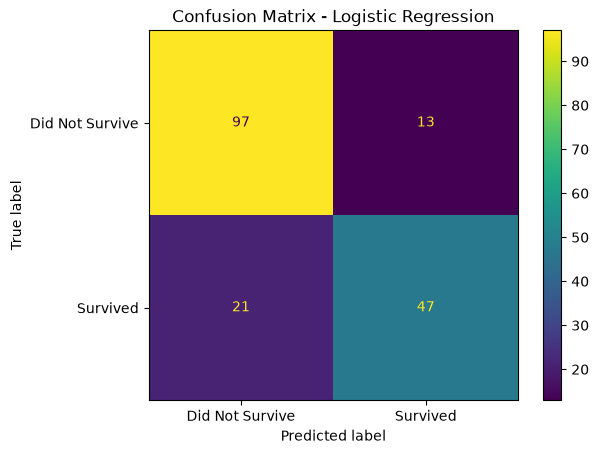

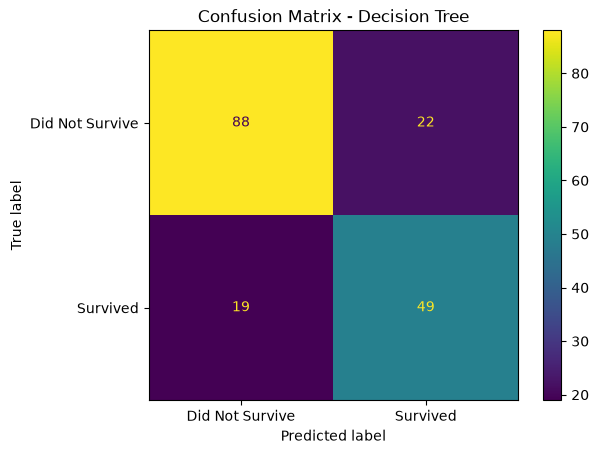

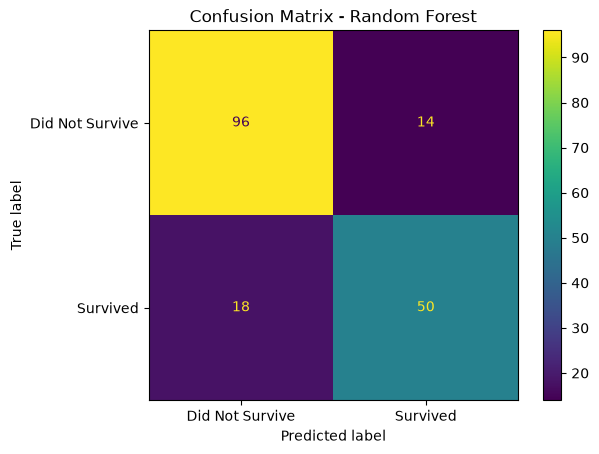

In [57]:
# Confusion Matrix — Logistic Regression
cm_logistic = confusion_matrix(y_test, y_pred_logistic)

disp_logistic = ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic,
    display_labels=["Did Not Survive", "Survived"]
)

disp_logistic.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


# Confusion Matrix — Decision Tree
cm_tree = confusion_matrix(y_test, y_pred_tree)

disp_tree = ConfusionMatrixDisplay(
    confusion_matrix=cm_tree,
    display_labels=["Did Not Survive", "Survived"]
)

disp_tree.plot()
plt.title("Confusion Matrix - Decision Tree")
plt.show()


# Confusion Matrix — Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

disp_rf = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Did Not Survive", "Survived"]
)

disp_rf.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [58]:
from sklearn.metrics import roc_curve, roc_auc_score

# Probability of class 1 (Survived)
y_prob_logistic = logistic_model.predict_proba(X_test_processed)[:, 1]
y_prob_tree = decision_tree_model.predict_proba(X_test_processed)[:, 1]
y_prob_rf = random_forest_model.predict_proba(X_test_processed)[:, 1]

print("Probability predictions generated successfully.")

Probability predictions generated successfully.


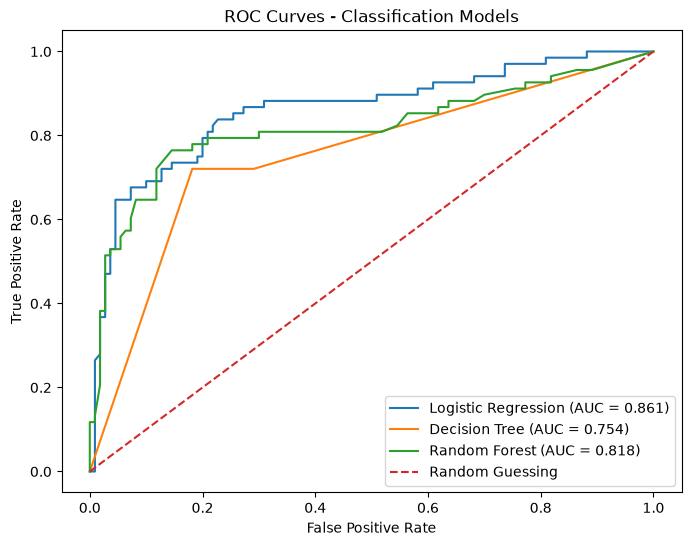

Logistic Regression AUC: 0.8609625668449199
Decision Tree AUC: 0.754144385026738
Random Forest AUC: 0.8179144385026736


In [59]:
# Calculate ROC curve values
fpr_logistic, tpr_logistic, _ = roc_curve(y_test, y_prob_logistic)
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_prob_tree)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

# Calculate AUC values
auc_logistic = roc_auc_score(y_test, y_prob_logistic)
auc_tree = roc_auc_score(y_test, y_prob_tree)
auc_rf = roc_auc_score(y_test, y_prob_rf)

# Plot ROC curves
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f"Logistic Regression (AUC = {auc_logistic:.3f})"
)

plt.plot(
    fpr_tree,
    tpr_tree,
    label=f"Decision Tree (AUC = {auc_tree:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {auc_rf:.3f})"
)

# Random guessing reference line
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guessing")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Classification Models")
plt.legend()
plt.show()

print("Logistic Regression AUC:", auc_logistic)
print("Decision Tree AUC:", auc_tree)
print("Random Forest AUC:", auc_rf)

In [60]:
feature_names = preprocessor.get_feature_names_out()

print("Number of features:", len(feature_names))
print("\nFeature names:")
print(feature_names)

Number of features: 10

Feature names:
['num__pclass' 'num__age' 'num__sibsp' 'num__parch' 'num__fare'
 'cat__sex_female' 'cat__sex_male' 'cat__embarked_C' 'cat__embarked_Q'
 'cat__embarked_S']


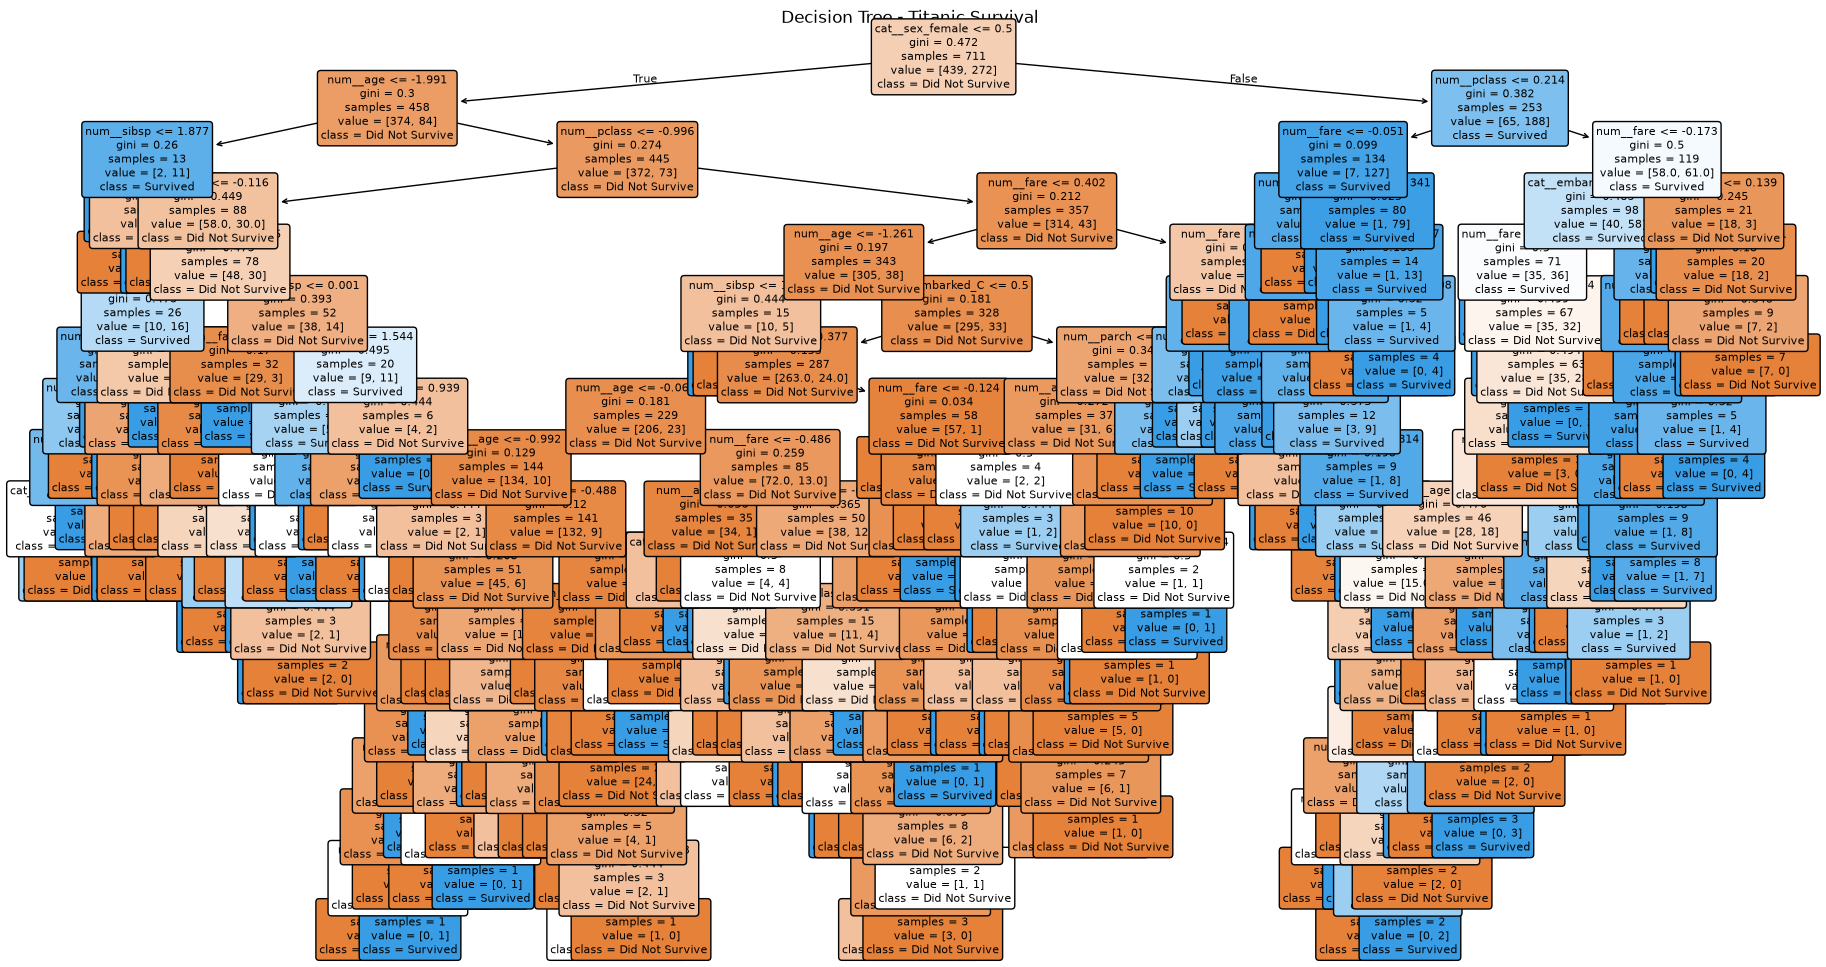

In [61]:
from sklearn.tree import plot_tree

plt.figure(figsize=(22, 12))

plot_tree(
    decision_tree_model,
    feature_names=feature_names,
    class_names=["Did Not Survive", "Survived"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree - Titanic Survival")
plt.show()

In [62]:
print("Training set class distribution:")
print(y_train.value_counts())

print("\nTraining set class percentages:")
print((y_train.value_counts(normalize=True) * 100).round(2))

Training set class distribution:
survived
0    439
1    272
Name: count, dtype: int64

Training set class percentages:
survived
0    61.74
1    38.26
Name: proportion, dtype: float64


In [63]:
rf_balanced = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42
)

rf_balanced.fit(X_train_processed, y_train)

y_pred_rf_balanced = rf_balanced.predict(X_test_processed)

print("Balanced Random Forest trained successfully.")

Balanced Random Forest trained successfully.


In [64]:
accuracy_rf_balanced = accuracy_score(y_test, y_pred_rf_balanced)
precision_rf_balanced = precision_score(y_test, y_pred_rf_balanced)
recall_rf_balanced = recall_score(y_test, y_pred_rf_balanced)
f1_rf_balanced = f1_score(y_test, y_pred_rf_balanced)

print("Balanced Random Forest Metrics")
print("--------------------------------")
print("Accuracy :", accuracy_rf_balanced)
print("Precision:", precision_rf_balanced)
print("Recall   :", recall_rf_balanced)
print("F1 Score :", f1_rf_balanced)

Balanced Random Forest Metrics
--------------------------------
Accuracy : 0.8033707865168539
Precision: 0.7391304347826086
Recall   : 0.75
F1 Score : 0.7445255474452555


In [65]:
%pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [66]:
from imblearn.over_sampling import SMOTE

print("SMOTE imported successfully.")

SMOTE imported successfully.


In [67]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

print("Original training class distribution:")
print(y_train.value_counts())

print("\nSMOTE training class distribution:")
print(y_train_smote.value_counts())

Original training class distribution:
survived
0    439
1    272
Name: count, dtype: int64

SMOTE training class distribution:
survived
1    439
0    439
Name: count, dtype: int64


In [68]:
rf_smote = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_smote.fit(X_train_smote, y_train_smote)

y_pred_rf_smote = rf_smote.predict(X_test_processed)

print("SMOTE Random Forest trained successfully.")

SMOTE Random Forest trained successfully.


In [69]:
accuracy_rf_smote = accuracy_score(y_test, y_pred_rf_smote)
precision_rf_smote = precision_score(y_test, y_pred_rf_smote)
recall_rf_smote = recall_score(y_test, y_pred_rf_smote)
f1_rf_smote = f1_score(y_test, y_pred_rf_smote)

print("SMOTE Random Forest Metrics")
print("---------------------------")
print("Accuracy :", accuracy_rf_smote)
print("Precision:", precision_rf_smote)
print("Recall   :", recall_rf_smote)
print("F1 Score :", f1_rf_smote)

SMOTE Random Forest Metrics
---------------------------
Accuracy : 0.7921348314606742
Precision: 0.746031746031746
Recall   : 0.6911764705882353
F1 Score : 0.7175572519083969


In [70]:
imbalance_results = pd.DataFrame({
    "Model": [
        "Baseline Random Forest",
        "Balanced Random Forest",
        "SMOTE Random Forest"
    ],
    "Accuracy": [
        accuracy_rf,
        accuracy_rf_balanced,
        accuracy_rf_smote
    ],
    "Precision": [
        precision_rf,
        precision_rf_balanced,
        precision_rf_smote
    ],
    "Recall": [
        recall_rf,
        recall_rf_balanced,
        recall_rf_smote
    ],
    "F1 Score": [
        f1_rf,
        f1_rf_balanced,
        f1_rf_smote
    ]
})

print(imbalance_results.round(4))

                    Model  Accuracy  Precision  Recall  F1 Score
0  Baseline Random Forest    0.8202     0.7812  0.7353    0.7576
1  Balanced Random Forest    0.8034     0.7391  0.7500    0.7445
2     SMOTE Random Forest    0.7921     0.7460  0.6912    0.7176


In [71]:
from sklearn.model_selection import GridSearchCV
print("GridSearchCV imported successfully.")

GridSearchCV imported successfully.


In [72]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10],
    "max_features": ["sqrt", "log2"]
}
print("Hyperparameter grid created successfully.")
print(param_grid)

Hyperparameter grid created successfully.
{'n_estimators': [50, 100, 200], 'max_depth': [None, 5, 10], 'max_features': ['sqrt', 'log2']}


In [73]:
from sklearn.ensemble import RandomForestClassifier
print("Random Forest imported successfully.")

Random Forest imported successfully.


In [74]:
rf_for_grid = RandomForestClassifier(
    random_state=42
)
print("Random Forest for GridSearchCV created successfully.")

Random Forest for GridSearchCV created successfully.


In [76]:
grid_search = GridSearchCV(
    estimator=rf_for_grid,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train_processed, y_train)

print("GridSearchCV completed successfully.")

GridSearchCV completed successfully.


In [77]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': 5, 'max_features': 'sqrt', 'n_estimators': 200}

Best Cross-Validation F1 Score:
0.7408312771917277


In [78]:
best_rf_model = grid_search.best_estimator_

print("Best tuned Random Forest obtained successfully.")
print(best_rf_model)

Best tuned Random Forest obtained successfully.
RandomForestClassifier(max_depth=5, n_estimators=200, random_state=42)


In [79]:
y_pred_tuned_rf = best_rf_model.predict(X_test_processed)

accuracy_tuned_rf = accuracy_score(y_test, y_pred_tuned_rf)
precision_tuned_rf = precision_score(y_test, y_pred_tuned_rf)
recall_tuned_rf = recall_score(y_test, y_pred_tuned_rf)
f1_tuned_rf = f1_score(y_test, y_pred_tuned_rf)

print("Tuned Random Forest Metrics")
print("---------------------------")
print("Accuracy :", accuracy_tuned_rf)
print("Precision:", precision_tuned_rf)
print("Recall   :", recall_tuned_rf)
print("F1 Score :", f1_tuned_rf)

Tuned Random Forest Metrics
---------------------------
Accuracy : 0.8314606741573034
Precision: 0.8653846153846154
Recall   : 0.6617647058823529
F1 Score : 0.75


In [80]:
rf_oob = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    max_features="sqrt",
    oob_score=True,
    random_state=42
)

rf_oob.fit(X_train_processed, y_train)

print("Random Forest with OOB evaluation trained successfully.")
print("OOB Score:", rf_oob.oob_score_)

Random Forest with OOB evaluation trained successfully.
OOB Score: 0.8213783403656821


In [81]:
regression_features = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "embarked"
]

X_reg = df_clean[regression_features]
y_reg = df_clean["fare"]

print("Regression features:")
print(regression_features)

print("\nX_reg shape:", X_reg.shape)
print("y_reg shape:", y_reg.shape)

Regression features:
['pclass', 'sex', 'age', 'sibsp', 'parch', 'embarked']

X_reg shape: (889, 6)
y_reg shape: (889,)


In [82]:
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

print("Regression train/test split completed.")
print("X_reg_train shape:", X_reg_train.shape)
print("X_reg_test shape:", X_reg_test.shape)
print("y_reg_train shape:", y_reg_train.shape)
print("y_reg_test shape:", y_reg_test.shape)

Regression train/test split completed.
X_reg_train shape: (711, 6)
X_reg_test shape: (178, 6)
y_reg_train shape: (711,)
y_reg_test shape: (178,)


In [83]:
reg_numeric_features = [
    "pclass",
    "age",
    "sibsp",
    "parch"
]

reg_categorical_features = [
    "sex",
    "embarked"
]

reg_numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

reg_categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

reg_preprocessor = ColumnTransformer(
    transformers=[
        ("num", reg_numeric_transformer, reg_numeric_features),
        ("cat", reg_categorical_transformer, reg_categorical_features)
    ]
)

print("Regression preprocessing pipeline created successfully.")

Regression preprocessing pipeline created successfully.


In [84]:
reg_preprocessor.fit(X_reg_train)

X_reg_train_processed = reg_preprocessor.transform(X_reg_train)
X_reg_test_processed = reg_preprocessor.transform(X_reg_test)

print("Regression preprocessing completed successfully.")
print("Processed training shape:", X_reg_train_processed.shape)
print("Processed testing shape:", X_reg_test_processed.shape)

Regression preprocessing completed successfully.
Processed training shape: (711, 9)
Processed testing shape: (178, 9)


In [ ]:
from sklearn.linear_model import LinearRegression
linear_regression_model = LinearRegression()
linear_regression_model.fit(
    X_reg_train_processed,
    y_reg_train
)

print("Linear Regression trained successfully.")

Linear Regression trained successfully.


In [86]:
y_reg_pred = linear_regression_model.predict(X_reg_test_processed)

print("Fare predictions generated successfully.")
print("First 10 predicted fares:")
print(y_reg_pred[:10])

Fare predictions generated successfully.
First 10 predicted fares:
[ -2.88475489  95.99511931  27.79356729  29.18366602  89.39234588
  -2.76586876  29.77809669  -2.05255195 100.4411708   84.37654661]


In [87]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_reg_test, y_reg_pred)

rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))

r2 = r2_score(y_reg_test, y_reg_pred)

n = len(y_reg_test)
p = X_reg_test_processed.shape[1]

adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

print("Linear Regression Metrics")
print("-------------------------")
print("MAE         :", mae)
print("RMSE        :", rmse)
print("R²          :", r2)
print("Adjusted R² :", adjusted_r2)

Linear Regression Metrics
-------------------------
MAE         : 21.138552296883116
RMSE        : 41.746502315739114
R²          : 0.34677389181134044
Adjusted R² : 0.3117796360155194


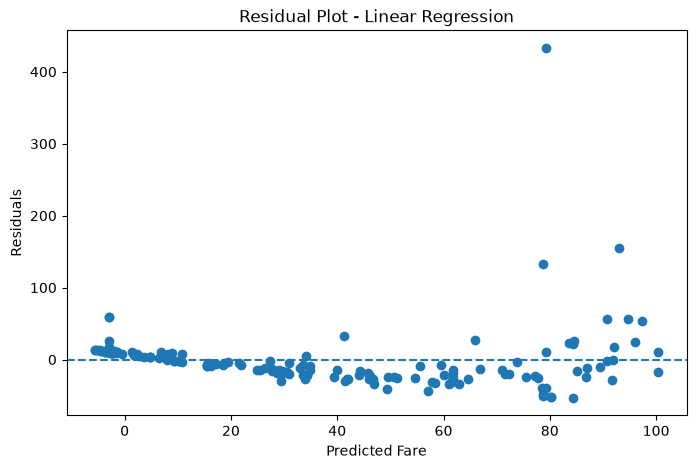

In [ ]:
residuals = y_reg_test - y_reg_pred
plt.figure(figsize=(8, 5))
plt.scatter(y_reg_pred, residuals)
plt.axhline(
    y=0,
    linestyle="--"
)
plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")
plt.title("Residual Plot - Linear Regression")
plt.show()

In [89]:
classification_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Balanced Random Forest",
        "SMOTE Random Forest",
        "Tuned Random Forest"
    ],
    "Accuracy": [
        accuracy_logistic,
        accuracy_tree,
        accuracy_rf,
        accuracy_rf_balanced,
        accuracy_rf_smote,
        accuracy_tuned_rf
    ],
    "Precision": [
        precision_logistic,
        precision_tree,
        precision_rf,
        precision_rf_balanced,
        precision_rf_smote,
        precision_tuned_rf
    ],
    "Recall": [
        recall_logistic,
        recall_tree,
        recall_rf,
        recall_rf_balanced,
        recall_rf_smote,
        recall_tuned_rf
    ],
    "F1 Score": [
        f1_logistic,
        f1_tree,
        f1_rf,
        f1_rf_balanced,
        f1_rf_smote,
        f1_tuned_rf
    ]
})

print(classification_results.round(4))

                    Model  Accuracy  Precision  Recall  F1 Score
0     Logistic Regression    0.8090     0.7833  0.6912    0.7344
1           Decision Tree    0.7697     0.6901  0.7206    0.7050
2           Random Forest    0.8202     0.7812  0.7353    0.7576
3  Balanced Random Forest    0.8034     0.7391  0.7500    0.7445
4     SMOTE Random Forest    0.7921     0.7460  0.6912    0.7176
5     Tuned Random Forest    0.8315     0.8654  0.6618    0.7500


In [90]:
regression_results = pd.DataFrame({
    "Model": ["Multivariate Linear Regression"],
    "MAE": [mae],
    "RMSE": [rmse],
    "R2": [r2],
    "Adjusted R2": [adjusted_r2]
})

print(regression_results.round(4))

                            Model      MAE     RMSE      R2  Adjusted R2
0  Multivariate Linear Regression  21.1386  41.7465  0.3468       0.3118


## Final Model Comparison and Recommendation

The classification models produced different performance across accuracy, precision, recall, F1 score, and AUC. The tuned Random Forest achieved the highest test accuracy (83.15%) and precision (86.54%), while the Balanced Random Forest achieved the highest recall (75.00%) among the Random Forest variants. The tuned Random Forest used `n_estimators=200`, `max_depth=5`, and `max_features='sqrt'`, with an OOB score of 82.14%. For the regression task, the Multivariate Linear Regression model achieved an MAE of 21.14, RMSE of 41.75, R² of 0.347, and Adjusted R² of 0.312, indicating that fare is only partially explained by the selected passenger features. Based on the classification results, the tuned Random Forest is a suitable model when accuracy and precision are important, while the balanced approach can be considered when greater recall is the priority.

In [92]:
from sklearn.pipeline import Pipeline

final_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", best_rf_model)
    ]
)

print("Complete ML pipeline created successfully.")

Complete ML pipeline created successfully.


In [ ]:
final_pipeline.fit(X_train, y_train)
print("Complete ML pipeline trained successfully.")

Complete ML pipeline trained successfully.


In [94]:
y_pred_pipeline = final_pipeline.predict(X_test)

print("Pipeline predictions generated successfully.")
print("First 20 predictions:")
print(y_pred_pipeline[:20])

Pipeline predictions generated successfully.
First 20 predictions:
[0 0 0 0 0 1 0 1 1 0 0 1 1 1 1 1 1 1 0 0]


In [95]:
import joblib
joblib.dump(final_pipeline, "full_pipeline.joblib")
print("Complete ML pipeline saved successfully.")

Complete ML pipeline saved successfully.


In [96]:
loaded_pipeline = joblib.load("full_pipeline.joblib")
print("Saved pipeline loaded successfully.")

Saved pipeline loaded successfully.


In [97]:
y_pred_loaded = loaded_pipeline.predict(X_test)

print("Predictions from reloaded pipeline:")
print(y_pred_loaded[:20])

Predictions from reloaded pipeline:
[0 0 0 0 0 1 0 1 1 0 0 1 1 1 1 1 1 1 0 0]


In [98]:
predictions_match = (y_pred_pipeline == y_pred_loaded).all()
print("Do both pipelines produce identical predictions?")
print(predictions_match)

Do both pipelines produce identical predictions?
True
